In [1]:
!pip install -q "numpy==1.26.4"

In [2]:
!pip install "transformer_lens==2.17.0"

In [3]:
import os
import json
import gc
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
from transformer_lens import HookedTransformer
from transformers import AutoTokenizer
from pathlib import Path
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from collections import Counter
import warnings
import logging

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", message=".*Glyph.*missing.*")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

2026-05-26 18:52:49.715499: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779821569.883237     125 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779821569.933694     125 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779821570.333166     125 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779821570.333201     125 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779821570.333203     125 computation_placer.cc:177] computation placer alr

In [4]:
# ── configuration ───────────────────────────────────────────────
CLASSIFIED_FILE = '/kaggle/input/datasets/svvikhlyantseva/classified-corrections-expanded-context/classified_corrections_expanded_context.json'
SOURCE_FILE     = '/kaggle/input/datasets/svvikhlyantseva/merged-results/merged_results.json'
OUTPUT_DIR      = '/kaggle/working/logit_lens_output'
MODEL_NAME      = 'Qwen/Qwen3-8B'

MAX_TOKENS   = 256   # prompt truncation — keeps the end (closest to the marker)
N_TOP_TOKENS = 5     # top-k tokens to report per layer
RANDOM_SEED  = 42
# ────────────────────────────────────────────────────────────────

np.random.seed(RANDOM_SEED)
Path(OUTPUT_DIR).mkdir(exist_ok=True)

In [5]:
# ── 2. MODEL LOADING ────────────────────────────────────────────

def load_model():
    print(f"\nLoading model {MODEL_NAME}...")
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    n_gpu  = torch.cuda.device_count()
    print(f"Device: {device}, GPUs: {n_gpu}")

    if n_gpu >= 2:
        model = HookedTransformer.from_pretrained(
            MODEL_NAME, device=None, n_devices=2,
            dtype=torch.float16, default_prepend_bos=False,
            fold_ln=False, center_writing_weights=False,
            move_to_device=True, trust_remote_code=True,
        )
    else:
        model = HookedTransformer.from_pretrained(
            MODEL_NAME, device=device,
            dtype=torch.float16, default_prepend_bos=False,
            fold_ln=False, center_writing_weights=False,
            trust_remote_code=True,
        )

    model.eval()
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

    print(f"Model: {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")
    for i in range(n_gpu):
        print(f"GPU {i}: {torch.cuda.memory_allocated(i)/1e9:.2f} GB")

    return model, tokenizer


model, tokenizer = load_model()


Loading model Qwen/Qwen3-8B...
Device: cuda, GPUs: 2


config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Loaded pretrained model Qwen/Qwen3-8B into HookedTransformer
Model: 36 layers, d_model=4096
GPU 0: 8.29 GB
GPU 1: 8.29 GB


In [7]:
# ── load vectors ─────────────────────────────────────────────────
saved = np.load(
    '/kaggle/input/datasets/svvikhlyantseva/'
    'updated-correction-vectors-all-methods/'
    'correction_vectors_all_methods (1).npz'
)

In [6]:
def generate_steered(model, tokenizer, prompt_text,
                     steering_vector=None, coeff=0,
                     steering_layer=None,
                     max_new_tokens=300,
                     only_last_position=True):
    messages = [{"role": "user", "content": prompt_text}]
    prefix   = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    ) + "<think>\n"
    prompt_tokens = tokenizer.encode(prefix)[-256:]

    # find the device of the steering layer once
    if (steering_vector is not None
            and coeff != 0
            and steering_layer is not None):
        layer_device = next(
            model.blocks[steering_layer].parameters()
        ).device
        # keep sv on CPU, move per-call — avoids stale device refs
        sv_cpu    = torch.tensor(steering_vector, dtype=torch.float32)
        hook_name = f'blocks.{steering_layer}.hook_resid_post'
        use_hook  = True
    else:
        use_hook = False

    input_t       = torch.tensor([prompt_tokens],
                                  dtype=torch.long, device='cuda:0')
    generated_ids = []
    think_closed  = False

    with torch.no_grad():
        current = input_t
        for _ in range(max_new_tokens):

            if use_hook and not think_closed:
                sv_dev = sv_cpu.to(layer_device).to(torch.float16)

                def steering_hook(value, hook,
                                   _sv=sv_dev, _c=coeff,
                                   _last=only_last_position):
                    _sv_local = _sv.to(value.device)
                    if _last:
                        value = value.clone()
                        value[:, -1, :] += _c * _sv_local
                    else:
                        value = value + _c * _sv_local
                    return value

                logits = model.run_with_hooks(
                    current,
                    fwd_hooks=[(hook_name, steering_hook)]
                )
            else:
                logits = model(current)

            next_tok = int(torch.argmax(logits[0, -1, :].cpu()).item())
            generated_ids.append(next_tok)

            current = torch.cat([
                current,
                torch.tensor([[next_tok]], dtype=torch.long, device='cuda:0')
            ], dim=1)

            decoded = tokenizer.decode(generated_ids)
            if '</think>' in decoded and not think_closed:
                think_closed = True   # stop steering, keep generating

            if next_tok == tokenizer.eos_token_id:
                break

    full = tokenizer.decode(generated_ids)
    if '</think>' in full:
        parts    = full.split('</think>', 1)
        thinking = parts[0]
        answer   = parts[1].strip()
    else:
        thinking = full
        answer   = ''

    return thinking, answer, think_closed

In [7]:
def count_correction_markers(text, markers=None):
    """Count self-correction markers in generated text."""
    if markers is None:
        markers = ['wait', 'actually', 'let me reconsider', 'correction',
                   'sorry', 'i meant', 'my mistake', 'on second thought',
                   'hang on', 'hold on', "that's not right", 'i made an error']
    text_lower = text.lower()
    counts = {m: text_lower.count(m) for m in markers if text_lower.count(m) > 0}
    return counts, sum(counts.values())

In [11]:
saved

NpzFile '/kaggle/input/datasets/svvikhlyantseva/updated-correction-vectors-all-methods/correction_vectors_all_methods (1).npz' with keys: dom_before, dom_on, dom_combined, mean_raw, mean_error_cf

In [12]:
# ── EXTRACT STYLISTIC HIGH AND ALL-WAIT VECTORS ───────────────────
# Exact same methodology as for genuine high-confidence cases:
# - per-case best_extraction_layer from logit lens
# - position_type from extraction_reason (before_marker or on_marker)
# - three variants: raw, error_cf, random_cf
# The only difference is the input case set.

# ── helpers (copied exactly from main_logit_lens_vector_extraction_steering.py) ──

def get_activation_at_layer(model, token_ids, layer):
    n_layers     = model.cfg.n_layers
    actual_layer = layer if layer >= 0 else n_layers + layer
    hook_name    = f'blocks.{actual_layer}.hook_resid_post'
    input_tensor = torch.tensor(
        [token_ids], dtype=torch.long
    ).to('cuda:0')
    captured = {}

    def hook_fn(value, hook):
        captured['resid'] = (
            value[0, -1, :].detach().cpu().float().numpy()
        )

    with torch.no_grad():
        model.run_with_hooks(
            input_tensor, fwd_hooks=[(hook_name, hook_fn)]
        )
    return captured['resid']


def get_counterfactual_token(model, tokenizer,
                              token_ids_before_marker, marker):
    marker_lower = marker.lower().strip()
    marker_ids   = set()
    for variant in [marker, ' ' + marker,
                    marker.capitalize(), ' ' + marker.capitalize(),
                    marker.upper(), ' ' + marker.upper()]:
        marker_ids |= set(
            tokenizer.encode(variant, add_special_tokens=False)
        )

    input_tensor = torch.tensor(
        [token_ids_before_marker], dtype=torch.long
    ).to('cuda:0')

    with torch.no_grad():
        logits = model(input_tensor)

    top_ids = torch.topk(logits[0, -1, :], k=20).indices.tolist()

    for tok_id in top_ids:
        decoded       = tokenizer.decode([tok_id])
        decoded_lower = decoded.lower().strip()
        if tok_id in marker_ids:
            continue
        if not decoded_lower:
            continue
        if marker_lower in decoded_lower:
            continue
        return tok_id, decoded

    return top_ids[-1], tokenizer.decode([top_ids[-1]])


def build_prefix(tokenizer, question_text):
    messages = [{"role": "user", "content": question_text}]
    prefix   = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    return prefix + "<think>\n"


def extract_vector_three_ways(model, tokenizer, case,
                               layer, max_tokens):
    """
    Exact replica of the function from
    main_logit_lens_vector_extraction_steering.py.
    Works for any case dict with context_before and extraction_reason.
    """
    context_before    = case.get('context_before', '')
    marker            = case['marker']
    extraction_reason = case.get('extraction_reason', '')

    if not context_before:
        return None

    prefix = build_prefix(tokenizer, case['question_text'])

    ids_with    = tokenizer.encode(
        prefix + context_before + ' ' + marker
    )[-max_tokens:]
    ids_without = tokenizer.encode(
        prefix + context_before
    )[-max_tokens:]

    if len(ids_with) < 10:
        return None

    # same position_type logic — now with English reasons
    # (after the translation patch applied earlier)
    reason_lower = extraction_reason.lower()
    if ('before' in reason_lower
            or 'маркер в топ до' in reason_lower
            or 'переход до маркера' in reason_lower):
        position_type = 'before_marker'
    else:
        position_type = 'on_marker'

    act_marker = get_activation_at_layer(model, ids_with, layer)

    # raw
    vec_raw = act_marker

    # error_cf
    cf_id, cf_str = get_counterfactual_token(
        model, tokenizer, ids_without, marker
    )
    ids_cf_error = (list(ids_without) + [cf_id])[-max_tokens:]
    act_cf_error = get_activation_at_layer(model, ids_cf_error, layer)
    vec_error_cf = act_marker - act_cf_error

    # random_cf
    random_id   = model.cfg.d_vocab // 2
    ids_cf_rand = (list(ids_without) + [random_id])[-max_tokens:]
    act_cf_rand = get_activation_at_layer(model, ids_cf_rand, layer)
    vec_rand_cf = act_marker - act_cf_rand

    return {
        'raw'             : vec_raw,
        'error_cf'        : vec_error_cf,
        'random_cf'       : vec_rand_cf,
        'layer'           : layer,
        'position_type'   : position_type,
        'marker'          : marker,
        'cf_token'        : cf_str,
        'question_id'     : case['question_id'],
        'extraction_reason': extraction_reason,
        'norm_raw'        : float(np.linalg.norm(vec_raw)),
        'norm_error_cf'   : float(np.linalg.norm(vec_error_cf)),
    }

In [18]:
# ── load logit lens layer assignments ────────────────────────────
with open(
    '/kaggle/input/datasets/svvikhlyantseva/cases-with-logit-lens-layers/cases_with_logit_lens_layers.json',
    'r', encoding='utf-8'
) as f:
    ll_cases = json.load(f)

ll_lookup = {
    (c['question_id'], c['occurrence_index']): c
    for c in ll_cases
}

with open(CLASSIFIED_FILE, 'r', encoding='utf-8') as f:
    classified_data = json.load(f)
with open(SOURCE_FILE, 'r', encoding='utf-8') as f:
    source_data = json.load(f)

source_lookup = {
    q['id']: q.get('question', '')
    for q in source_data.get('questions', [])
}

In [8]:
def build_cases(classified_data, source_lookup, ll_lookup,
                filter_cls=None, filter_conf=None,
                marker_filter='wait'):
    """
    Build a case list from classified data.
    filter_cls:  None = all, 'genuine_correction', 'stylistic_filler'
    filter_conf: None = all, 'high', 'medium', 'low'
    """
    cases = []
    for q in classified_data.get('questions', []):
        q_id = q['id']
        for mb in q.get('markers', []):
            if mb['marker'] != marker_filter:
                continue
            for cls in mb.get('classifications', []):
                if filter_cls and cls.get('classification') != filter_cls:
                    continue
                if filter_conf and cls.get('confidence') != filter_conf:
                    continue

                occ_idx = cls.get('occurrence_index', 1)
                ll_info = ll_lookup.get((q_id, occ_idx), {})

                cases.append({
                    'question_id'          : q_id,
                    'question_text'        : source_lookup.get(q_id, ''),
                    'marker'               : marker_filter,
                    'occurrence_index'     : occ_idx,
                    'classification'       : cls.get('classification', ''),
                    'confidence'           : cls.get('confidence', ''),
                    'context_before'       : cls.get('context_before', ''),
                    'best_extraction_layer': ll_info.get(
                        'best_extraction_layer', 30
                    ),
                    'extraction_reason'    : ll_info.get(
                        'extraction_reason', ''
                    ),
                })
    return cases

In [21]:
# build all three case sets
stylistic_hc_cases = build_cases(
    classified_data, source_lookup, ll_lookup,
    filter_cls='stylistic_filler', filter_conf='high'
)
all_wait_cases = build_cases(
    classified_data, source_lookup, ll_lookup,
    filter_cls=None, filter_conf=None  # no filter
)

print(f"Stylistic high-confidence: {len(stylistic_hc_cases)}")
print(f"All wait cases (no filter): {len(all_wait_cases)}")

Stylistic high-confidence: 255
All wait cases (no filter): 924


In [22]:
# ── extraction loop ───────────────────────────────────────────────

def run_extraction_loop(model, tokenizer, cases, label, max_tokens):
    raw_vecs, error_cf_vecs, rand_cf_vecs = [], [], []
    skipped = 0

    print(f"\n{'='*65}")
    print(f"EXTRACTING: {label}  ({len(cases)} cases)")
    print(f"{'='*65}")

    for i, case in enumerate(cases):
        layer = case.get('best_extraction_layer', 30)

        torch.cuda.empty_cache()
        gc.collect()

        result = extract_vector_three_ways(
            model, tokenizer, case, layer, max_tokens
        )

        if result is None:
            skipped += 1
            continue

        raw_vecs.append(result['raw'])
        error_cf_vecs.append(result['error_cf'])
        rand_cf_vecs.append(result['random_cf'])

        if (i + 1) % 50 == 0:
            print(f"  [{i+1}/{len(cases)}]")

    print(f"  Done: {len(raw_vecs)} extracted, {skipped} skipped")
    return raw_vecs, error_cf_vecs, rand_cf_vecs


# run for stylistic high-confidence
sty_raw, sty_ecf, sty_rcf = run_extraction_loop(
    model, tokenizer, stylistic_hc_cases,
    'stylistic high-confidence', MAX_TOKENS
)

# run for all wait cases
all_raw, all_ecf, all_rcf = run_extraction_loop(
    model, tokenizer, all_wait_cases,
    'all wait cases (no filter)', MAX_TOKENS
)


EXTRACTING: stylistic high-confidence  (255 cases)
  [50/255]
  [100/255]
  [150/255]
  [200/255]
  [250/255]
  Done: 255 extracted, 0 skipped

EXTRACTING: all wait cases (no filter)  (924 cases)
  [50/924]
  [100/924]
  [150/924]
  [200/924]
  [250/924]
  [300/924]
  [350/924]
  [400/924]
  [450/924]
  [500/924]
  [550/924]
  [600/924]
  [650/924]
  [700/924]
  [750/924]
  [800/924]
  [850/924]
  [900/924]
  Done: 924 extracted, 0 skipped


In [23]:
# ── compute mean vectors ──────────────────────────────────────────

mean_stylistic_raw      = np.mean(sty_raw, axis=0)
mean_stylistic_error_cf = np.mean(sty_ecf, axis=0)

mean_all_raw      = np.mean(all_raw, axis=0)
mean_all_error_cf = np.mean(all_ecf, axis=0)

In [24]:
# ── cosine similarity comparison ──────────────────────────────────

from sklearn.metrics.pairwise import cosine_similarity

def norm(v):
    return v.astype(np.float32) / (np.linalg.norm(v) + 1e-8)

# load genuine vector for comparison
saved_existing = np.load(
    '/kaggle/input/datasets/svvikhlyantseva/'
    'updated-correction-vectors-all-methods/'
    'correction_vectors_all_methods (1).npz'
)
sv_genuine = norm(saved_existing['mean_raw'])

sv_stylistic = norm(mean_stylistic_raw)
sv_all       = norm(mean_all_raw)

pairs = [
    ('genuine_hc',   sv_genuine),
    ('stylistic_hc', sv_stylistic),
    ('all_wait',     sv_all),
]

print("\n" + "="*55)
print("COSINE SIMILARITY BETWEEN MEAN VECTORS (raw)")
print("="*55)
for i, (n1, v1) in enumerate(pairs):
    for n2, v2 in pairs[i+1:]:
        s = float(cosine_similarity(
            v1.reshape(1,-1), v2.reshape(1,-1)
        )[0,0])
        print(f"  {n1} vs {n2}: {s:.4f}")

print("\nInterpretation:")
print("  genuine_hc vs stylistic_hc: if low → filtering matters")
print("  genuine_hc vs all_wait:     if low → genuine-only is cleaner")
print("  stylistic_hc vs all_wait:   if high → all_wait dominated by stylistic")


COSINE SIMILARITY BETWEEN MEAN VECTORS (raw)
  genuine_hc vs stylistic_hc: 0.2305
  genuine_hc vs all_wait: 0.1935
  stylistic_hc vs all_wait: 0.9957

Interpretation:
  genuine_hc vs stylistic_hc: if low → filtering matters
  genuine_hc vs all_wait:     if low → genuine-only is cleaner
  stylistic_hc vs all_wait:   if high → all_wait dominated by stylistic


In [25]:
# ── save everything ───────────────────────────────────────────────

existing = dict(saved_existing)
existing['mean_stylistic']           = mean_stylistic_raw
existing['mean_stylistic_error_cf']  = mean_stylistic_error_cf
existing['mean_all_wait']            = mean_all_raw
existing['mean_all_wait_error_cf']   = mean_all_error_cf

save_path = (
    '/kaggle/working/logit_lens_output/'
    'correction_vectors_all_methods_extended.npz'
)
np.savez(save_path, **existing)
print(f"\nSaved: {save_path}")
print("Keys:", list(existing.keys()))


Saved: /kaggle/working/logit_lens_output/correction_vectors_all_methods_extended.npz
Keys: ['dom_before', 'dom_on', 'dom_combined', 'mean_raw', 'mean_error_cf', 'mean_stylistic', 'mean_stylistic_error_cf', 'mean_all_wait', 'mean_all_wait_error_cf']


In [13]:
saved = np.load('/kaggle/input/datasets/svvikhlyantseva/correction-vectors-all-methods-extended/correction_vectors_all_methods_extended.npz')

STEERING_LAYER = 21

raw_vec       = saved['mean_raw']
dom_vec       = saved['dom_combined'][STEERING_LAYER]
error_cf_vec  = saved['mean_error_cf']
all_wait_vec = saved['mean_all_wait']

# normalise all to unit norm — same scale for fair comparison
def norm(v):
    return v / (np.linalg.norm(v) + 1e-8)

sv_raw      = norm(raw_vec.astype(np.float32))
sv_dom      = norm(dom_vec.astype(np.float32))
sv_error_cf = norm(error_cf_vec.astype(np.float32))
sv_all_wait = norm(all_wait_vec.astype(np.float32))

np.random.seed(RANDOM_SEED)
sv_rand = np.random.randn(model.cfg.d_model).astype(np.float32)
sv_rand = norm(sv_rand)

print("Cosine similarities (sanity check):")
vectors_to_compare = [
    ('genuine', sv_genuine),
    ('all_wait', sv_all_wait),
    ('dom_combined', sv_dom),
    ('error_cf', sv_error_cf),
    ('random', sv_rand)
]

for i, (n1, v1) in enumerate(vectors_to_compare):
    for n2, v2 in vectors_to_compare[i+1:]:
        s = float(cosine_similarity(v1.reshape(1,-1), v2.reshape(1,-1))[0,0])
        print(f"  {n1} vs {n2}: {s:.4f}")

Cosine similarities (sanity check):
  genuine vs all_wait: 0.1935
  genuine vs dom_combined: 0.5361
  genuine vs error_cf: 0.6528
  genuine vs random: 0.0041
  all_wait vs dom_combined: 0.1702
  all_wait vs error_cf: 0.0751
  all_wait vs random: 0.0103
  dom_combined vs error_cf: 0.3606
  dom_combined vs random: -0.0029
  error_cf vs random: 0.0045


In [17]:
# ════════════════════════════════════════════════════════════════
# PART 1: AIME — comparison of all vector types
# ════════════════════════════════════════════════════════════════

# load AIME and match
from datasets import load_dataset

aime_ds = load_dataset("MathArena/aime_2025", split="train")
aime_lookup = {
    ' '.join(item['problem'].strip().split()): int(item['answer'])
    for item in aime_ds
}

with open(SOURCE_FILE, 'r', encoding='utf-8') as f:
    source = json.load(f)

GROUND_TRUTH   = {}
math_questions = []
for q in source['questions']:
    if q.get('category') != 'math_trick':
        continue
    q_norm = ' '.join(q['question'].strip().split())
    if q_norm in aime_lookup:
        GROUND_TRUTH[q['id']] = aime_lookup[q_norm]
        math_questions.append(q)

print(f"\nMatched AIME questions: {len(math_questions)}")

AIME_SUBSET  = math_questions[:8]   # 8 questions × 5 conditions × ~3min = ~1.5h
COEFF_POS    = 40
MAX_TOK_AIME = 600   # change to 1500 for accuracy attempt

# Обновляем словарь векторов - теперь 5 типов
AIME_VECTORS = {
    'genuine_hc': sv_genuine,
    'all_wait': sv_all_wait,
    'dom_combined': sv_dom,
    'error_cf': sv_error_cf,
    'random': sv_rand,
}

results_aime = {vn: {'markers': [], 'tokens': []} 
                for vn in list(AIME_VECTORS.keys()) + ['baseline']}
aime_records = []

print("\n" + "="*65)
print(f"PART 1: AIME  |  coeff={COEFF_POS}  |  layer={STEERING_LAYER}")
print(f"n={len(AIME_SUBSET)}  |  max_tokens={MAX_TOK_AIME}")
print(f"Vectors compared: {list(AIME_VECTORS.keys())}")
print("="*65)

for p_idx, q in enumerate(AIME_SUBSET):
    q_id   = q['id']
    q_text = q['question']
    gt     = GROUND_TRUTH[q_id]
    record = {'question_id': q_id, 'gt': gt,
              'question': q_text[:80], 'conditions': []}

    print(f"\n[{p_idx+1}/{len(AIME_SUBSET)}] Q{q_id} | GT={gt}")
    print(f"  {q_text[:80]}...")

    # baseline
    torch.cuda.empty_cache(); gc.collect()
    thinking_b, answer_b, closed_b = generate_steered(
        model, tokenizer, q_text,
        steering_vector=None, coeff=0,
        steering_layer=None,
        max_new_tokens=MAX_TOK_AIME,
    )
    _, n_b   = count_correction_markers(thinking_b)
    n_tok_b  = len(tokenizer.encode(thinking_b))
    pred_b   = extract_aime_answer(answer_b, q_text)
    corr_b   = int(pred_b == gt) if pred_b is not None else 0

    results_aime['baseline']['markers'].append(n_b)
    results_aime['baseline']['tokens'].append(n_tok_b)
    print(f"  [baseline] markers={n_b} tokens={n_tok_b} "
          f"pred={pred_b} correct={bool(corr_b)} closed={closed_b}")

    record['conditions'].append({
        'vector': 'baseline', 'coeff': 0,
        'markers': n_b, 'tokens': n_tok_b,
        'predicted': pred_b, 'correct': corr_b, 'closed': closed_b,
        'thinking': thinking_b[:400], 'answer': answer_b[:200],
    })

    # steered - теперь для всех 5 типов векторов
    for vec_name, sv in AIME_VECTORS.items():
        torch.cuda.empty_cache(); gc.collect()

        thinking_s, answer_s, closed_s = generate_steered(
            model, tokenizer, q_text,
            steering_vector=sv,
            coeff=COEFF_POS,
            steering_layer=STEERING_LAYER,
            max_new_tokens=MAX_TOK_AIME,
        )
        _, n_s   = count_correction_markers(thinking_s)
        n_tok_s  = len(tokenizer.encode(thinking_s))
        pred_s   = extract_aime_answer(answer_s, q_text)
        corr_s   = int(pred_s == gt) if pred_s is not None else 0

        results_aime[vec_name]['markers'].append(n_s)
        results_aime[vec_name]['tokens'].append(n_tok_s)

        print(f"  [{vec_name} c={COEFF_POS}] markers={n_s} "
              f"tokens={n_tok_s} pred={pred_s} "
              f"correct={bool(corr_s)} closed={closed_s}")
        print(f"    {thinking_s[100:300]}...")

        record['conditions'].append({
            'vector': vec_name, 'coeff': COEFF_POS,
            'markers': n_s, 'tokens': n_tok_s,
            'predicted': pred_s, 'correct': corr_s,
            'closed': closed_s,
            'thinking': thinking_s[:400], 'answer': answer_s[:200],
        })

    aime_records.append(record)
    with open(f'{OUTPUT_DIR}/aime_all_vectors_comparison.json', 'w') as f:
        json.dump(aime_records, f, ensure_ascii=False, indent=2)


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/14.3k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30 [00:00<?, ? examples/s]


Matched AIME questions: 30

PART 1: AIME  |  coeff=40  |  layer=21
n=8  |  max_tokens=600
Vectors compared: ['genuine_hc', 'all_wait', 'dom_combined', 'error_cf', 'random']

[1/8] Q3 | GT=237
  Let $A$ be the set of positive integer divisors of $2025$. Let $B$ be a randomly...
  [baseline] markers=4 tokens=600 pred=None correct=False closed=False
  [genuine_hc c=40] markers=6 tokens=600 pred=None correct=False closed=False
     set of positive integer divisors of 2025) is nonempty and has the property that the least common multiple (LCM) of its elements is 2025. Then, express this probability as a reduced fraction m/n and f...
  [all_wait c=40] markers=5 tokens=600 pred=None correct=False closed=False
    ts of the positive integer divisors of 2025) is nonempty and has the property that the least common multiple (LCM) of its elements is 2025. Then, express this probability as a reduced fraction m/n and...
  [dom_combined c=40] markers=3 tokens=600 pred=None correct=False closed=False


In [18]:
# ── Part 1 statistics ─────────────────────────────────────────────
print("\n" + "="*65)
print("PART 1 RESULTS - All Vectors Comparison")
print("="*65)

all_vecs_p1 = ['baseline'] + list(AIME_VECTORS.keys())
print("\nMean markers (±std):")
for vn in all_vecs_p1:
    d = results_aime[vn]
    print(f"  {vn:>15}: markers={np.mean(d['markers']):.2f}"
          f"±{np.std(d['markers']):.2f}  "
          f"tokens={np.mean(d['tokens']):.0f}")

# Статистические тесты - сравнение всех векторов с random
rand_m = results_aime['random']['markers']
print("\n  Mann-Whitney U (H1: vector > random, markers):")
for vn in ['genuine_hc', 'all_wait', 'dom_combined', 'error_cf']:
    vals = results_aime[vn]['markers']
    stat, p = stats.mannwhitneyu(vals, rand_m, alternative='greater')
    sig = 'p<0.05 ✓' if p < 0.05 else 'not significant'
    print(f"    {vn:>15}: p={p:.4f}  {sig}")

# Сравнение между разными векторами
print("\n  Pairwise comparisons (H1: genuine_hc > others):")
for vn in ['all_wait', 'dom_combined', 'error_cf']:
    stat, p = stats.mannwhitneyu(
        results_aime['genuine_hc']['markers'],
        results_aime[vn]['markers'],
        alternative='greater'
    )
    sig = 'p<0.05 ✓' if p < 0.05 else 'not significant'
    print(f"    genuine_hc vs {vn:>15}: p={p:.4f}  {sig}")


PART 1 RESULTS - All Vectors Comparison

Mean markers (±std):
         baseline: markers=2.62±2.34  tokens=600
       genuine_hc: markers=4.50±3.39  tokens=600
         all_wait: markers=3.38±2.91  tokens=600
     dom_combined: markers=4.75±3.15  tokens=600
         error_cf: markers=4.38±3.16  tokens=600
           random: markers=3.88±3.66  tokens=600

  Mann-Whitney U (H1: vector > random, markers):
         genuine_hc: p=0.3943  not significant
           all_wait: p=0.6056  not significant
       dom_combined: p=0.3748  not significant
           error_cf: p=0.3344  not significant

  Pairwise comparisons (H1: genuine_hc > others):
    genuine_hc vs        all_wait: p=0.2972  not significant
    genuine_hc vs    dom_combined: p=0.5211  not significant
    genuine_hc vs        error_cf: p=0.5635  not significant


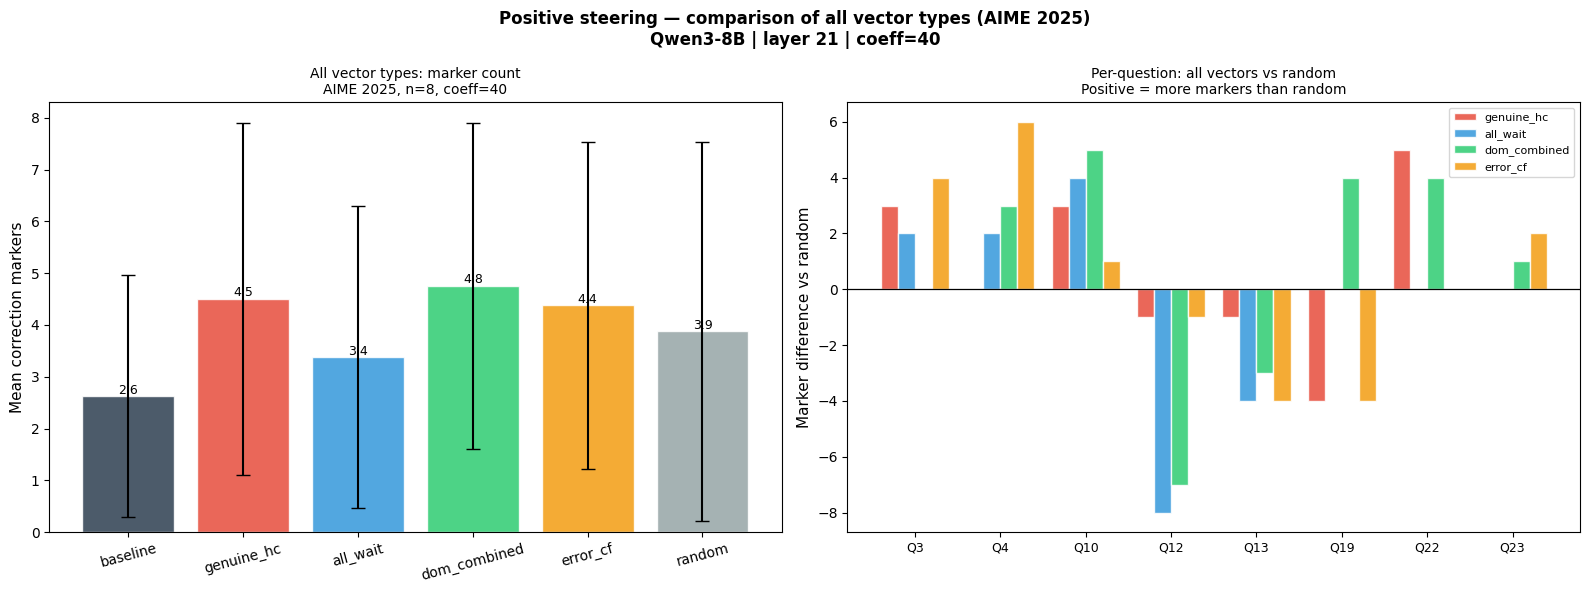

In [19]:
# ── Part 1 figure ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot for all vectors
means_m = [np.mean(results_aime[vn]['markers']) for vn in all_vecs_p1]
stds_m  = [np.std(results_aime[vn]['markers'])  for vn in all_vecs_p1]
colors  = ['#2c3e50', '#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#95a5a6']

bars = axes[0].bar(all_vecs_p1, means_m, color=colors, alpha=0.85,
            yerr=stds_m, capsize=5, edgecolor='white')
for bar, val in zip(bars, means_m):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.1f}', ha='center', fontsize=9)
axes[0].set_ylabel('Mean correction markers', fontsize=11)
axes[0].set_title(
    f'All vector types: marker count\n'
    f'AIME 2025, n={len(AIME_SUBSET)}, coeff={COEFF_POS}',
    fontsize=10
)
axes[0].tick_params(axis='x', rotation=15)

# Difference from random for each vector
x = np.arange(len(AIME_SUBSET))
w = 0.2  # ширина для 4 типов векторов
offsets = [-0.3, -0.1, 0.1, 0.3]
vector_names = ['genuine_hc', 'all_wait', 'dom_combined', 'error_cf']
colors_vec = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, (vn, col) in enumerate(zip(vector_names, colors_vec)):
    diffs = [g - r for g, r in zip(results_aime[vn]['markers'], rand_m)]
    axes[1].bar(x + offsets[i], diffs, w, label=vn,
                color=col, alpha=0.85, edgecolor='white')

axes[1].axhline(0, color='black', linewidth=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Q{q["id"]}' for q in AIME_SUBSET], fontsize=9)
axes[1].set_ylabel('Marker difference vs random', fontsize=11)
axes[1].set_title(
    'Per-question: all vectors vs random\n'
    'Positive = more markers than random',
    fontsize=10
)
axes[1].legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Positive steering — comparison of all vector types (AIME 2025)\n'
    f'Qwen3-8B | layer {STEERING_LAYER} | coeff={COEFF_POS}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/aime_all_vectors_comparison.png',
            dpi=130, bbox_inches='tight')
plt.show()
plt.close()

Странное поведение, может, символы в условии задачи вызывали, из-за этого недостоверные результаты эффекта векторов Wait, actually, the original problem might be in Chinese, but the user provided a TikZ diagram

Wait, the original problem might be about some properties or maybe a specific question? Hmm, the user hasn't provided the exact question, 

In [22]:
saved = np.load(
    '/kaggle/input/datasets/svvikhlyantseva/correction-vectors-all-methods-extended/correction_vectors_all_methods_extended.npz'
)

sv_genuine   = norm(saved['mean_raw'])           # genuine high-conf only
sv_all_wait  = norm(saved['mean_all_wait'])      # all wait, no filter

sv_sty_raw   = norm(saved['mean_stylistic'])           # stylistic high-conf raw
sv_sty_ecf   = norm(saved['mean_stylistic_error_cf'])  # stylistic high-conf error_cf

np.random.seed(RANDOM_SEED)
sv_rand = norm(np.random.randn(sv_genuine.shape[0]).astype(np.float32))

print("Cosine similarities (sanity check):")
for n1, v1 in [('genuine', sv_genuine), ('all_wait', sv_all_wait)]:
    for n2, v2 in [('all_wait', sv_all_wait), ('random', sv_rand)]:
        if n1 == n2:
            continue
        s = float(cosine_similarity(v1.reshape(1,-1), v2.reshape(1,-1))[0,0])
        print(f"  {n1} vs {n2}: {s:.4f}")

Cosine similarities (sanity check):
  genuine vs all_wait: 0.1935
  genuine vs random: 0.0041
  all_wait vs random: 0.0103


In [15]:
# ── helper functions ──────────────────────────────────────────────

def count_correction_markers(text, markers=None):
    if markers is None:
        markers = ['wait', 'actually', 'let me reconsider',
                   'correction', 'i meant', 'my mistake',
                   'on second thought', 'hang on', 'hold on',
                   "that's not right", 'i made an error']
    t = text.lower()
    counts = {m: t.count(m) for m in markers if t.count(m) > 0}
    return counts, sum(counts.values())


def score_answer(answer_text, ground_truth):
    return int(str(ground_truth).lower() in answer_text.lower())


def extract_aime_answer(answer_text, question_text=''):
    q_nums = set(re.findall(r'\b\d+\b', question_text))
    boxed  = re.findall(r'\\boxed\{(\d+)\}', answer_text)
    if boxed:
        return int(boxed[-1])
    for pat in [r'(?:answer is|=)\s*\**(\d+)\**',
                r'm\s*\+\s*n\s*=\s*(\d+)',
                r'therefore[,\s]+(\d+)']:
        found = re.findall(pat, answer_text.lower())
        if found:
            c = int(found[-1])
            if 0 <= c <= 999:
                return c
    nums = re.findall(r'\b(\d{1,3})\b', answer_text)
    for num in reversed(nums):
        c = int(num)
        if str(c) not in q_nums and 0 <= c <= 999:
            return c
    return None

In [26]:
STEERING_LAYER = 21

In [37]:
# ════════════════════════════════════════════════════════════════
# PART 2: SIMPLE PROMPTS — negative stylistic steering vs random
# ════════════════════════════════════════════════════════════════

SIMPLE_PROMPTS = [
    "What is the capital of Australia? Think step by step.",
    "How many days are in a leap year? Think carefully.",
    "What is 2 + 2? Explain your answer step by step.",
    "What color is the sky on a clear day? Think carefully.",
    "Name the days of the week in order.",
    "What language do people speak in France? Think step by step.",
    "How many months are in a year? Think carefully.",
    "What is the chemical symbol for water? Explain.",
    "How many sides does a triangle have? Show your reasoning.",
    "What continent is Brazil on? Think step by step.",
]

SIMPLE_GT = {
    "What is the capital of Australia? Think step by step."     : "Canberra",
    "How many days are in a leap year? Think carefully."        : "366",
    "What is 2 + 2? Explain your answer step by step."         : "4",
    "What color is the sky on a clear day? Think carefully."    : "blue",
    "Name the days of the week in order."                       : "Monday",
    "What language do people speak in France? Think step by step.": "French",
    "How many months are in a year? Think carefully."           : "12",
    "What is the chemical symbol for water? Explain."           : "H2O",
    "How many sides does a triangle have? Show your reasoning." : "three",
    "What continent is Brazil on? Think step by step."         : "South America",
}

NEG_COEFF = -70   # negative - subtract vector from residual stream

NEG_VECTORS = {
    'neg_sty_raw' : sv_sty_raw,    # subtract stylistic
    'neg_sty_ecf' : sv_sty_ecf,    
    'random'      : sv_rand,
}

neg_records = []

print("\n" + "="*65)
print(f"PART 2: SIMPLE PROMPTS — negative stylistic steering")
print(f"coeff={NEG_COEFF}  |  layer={STEERING_LAYER}  |  n={len(SIMPLE_PROMPTS)}")
print("="*65)

for p_idx, prompt_text in enumerate(SIMPLE_PROMPTS):
    gt     = SIMPLE_GT.get(prompt_text, '')
    record = {'prompt': prompt_text[:80], 'gt': gt, 'conditions': []}
    print(f"\n{'─'*65}")
    print(f"[{p_idx+1}/{len(SIMPLE_PROMPTS)}] Q: {prompt_text[:60]}")

    # baseline
    torch.cuda.empty_cache(); gc.collect()
    thinking_b, answer_b, closed_b = generate_steered(
        model, tokenizer, prompt_text,
        steering_vector=None, coeff=0,
        steering_layer=None, max_new_tokens=500,
    )
    _, n_b_m = count_correction_markers(thinking_b)
    n_b_tok  = len(tokenizer.encode(thinking_b))
    corr_b   = score_answer(thinking_b + answer_b, gt)

    print(f"  [baseline] markers={n_b_m} tokens={n_b_tok} correct={bool(corr_b)} closed={closed_b}")
    print(f"    Thinking: {thinking_b[:250]}...")
    print(f"    Answer:   {answer_b[:150]}")

    record['conditions'].append({
        'vector': 'baseline', 'coeff': 0,
        'markers': n_b_m, 'tokens': n_b_tok,
        'correct': corr_b, 'closed': closed_b,
        'thinking': thinking_b[:500], 'answer': answer_b,
    })

    for vec_name, sv in NEG_VECTORS.items():
        torch.cuda.empty_cache(); gc.collect()

        thinking_s, answer_s, closed_s = generate_steered(
            model, tokenizer, prompt_text,
            steering_vector=sv,
            coeff=NEG_COEFF,
            steering_layer=STEERING_LAYER,
            max_new_tokens=500,
        )
        _, n_s_m = count_correction_markers(thinking_s)
        n_s_tok  = len(tokenizer.encode(thinking_s))
        corr_s   = score_answer(thinking_s + answer_s, gt)

        print(f"  [{vec_name} c={NEG_COEFF}] markers={n_s_m} "
              f"tokens={n_s_tok} correct={bool(corr_s)} closed={closed_s}")
        print(f"    Thinking: {thinking_s[:250]}...")
        print(f"    Answer:   {answer_s[:150]}")

        record['conditions'].append({
            'vector': vec_name, 'coeff': NEG_COEFF,
            'markers': n_s_m, 'tokens': n_s_tok,
            'correct': corr_s, 'closed': closed_s,
            'thinking': thinking_s[:500], 'answer': answer_s,
        })

    neg_records.append(record)
    with open(f'{OUTPUT_DIR}/neg_stylistic_vs_random.json', 'w') as f:
        json.dump(neg_records, f, ensure_ascii=False, indent=2)


PART 2: SIMPLE PROMPTS — negative stylistic steering
coeff=-70  |  layer=21  |  n=10

─────────────────────────────────────────────────────────────────
[1/10] Q: What is the capital of Australia? Think step by step.
  [baseline] markers=3 tokens=476 correct=True closed=True
    Thinking: Okay, so I need to figure out the capital of Australia. Let me start by recalling what I know. I remember that Australia is a country in the Southern Hemisphere, and it's known for its unique wildlife and landscapes. But when it comes to capitals, I'...
    Answer:   The capital of Australia is **Canberra**. Here's a step-by-step breakdown:

1. **Understanding
  [neg_sty_raw c=-70] markers=2 tokens=500 correct=True closed=False
    Thinking: Okay, so I need to figure out the capital of Australia. Let me start by recalling what I know. I remember that Australia is a country in the southern hemisphere, and it's known for things like the Great Barrier Reef, Uluru, and its unique wildlife. B...
    Answer

In [41]:
# rebuild results_neg from neg_records
# first figure out which vector names are present
vec_names = set()
for record in neg_records:
    for cond in record['conditions']:
        vec_names.add(cond['vector'])

results_neg = {vn: {'markers': [], 'tokens': [], 'correct': []}
               for vn in vec_names}

def score_answer_fixed(answer_text, thinking_text, ground_truth):
    """Handles unicode subscripts: H₂O == H2O."""
    combined = (answer_text + thinking_text).lower()
    gt       = ground_truth.lower()
    for src, dst in [('₀','0'),('₁','1'),('₂','2'),('₃','3'),
                     ('₄','4'),('₅','5'),('₆','6'),('₇','7'),
                     ('₈','8'),('₉','9')]:
        combined = combined.replace(src, dst)
        gt       = gt.replace(src, dst)
    return int(gt in combined)

for record in neg_records:
    gt = record.get('gt', '')
    for cond in record['conditions']:
        vn = cond['vector']
        results_neg[vn]['markers'].append(cond.get('markers', 0))
        results_neg[vn]['tokens'].append(cond.get('tokens', 0))
        results_neg[vn]['correct'].append(
            score_answer_fixed(
                cond.get('answer', ''),
                cond.get('thinking', ''),
                gt
            )
        )

print("Rebuilt results_neg:")
for vn, d in results_neg.items():
    acc = sum(d['correct']) / len(d['correct']) if d['correct'] else 0
    print(f"  {vn:>15}: markers={np.mean(d['markers']):.2f}  "
          f"tokens={np.mean(d['tokens']):.0f}  "
          f"acc={acc:.0%} ({sum(d['correct'])}/{len(d['correct'])})")

Rebuilt results_neg:
      neg_sty_ecf: markers=1.00  tokens=424  acc=80% (8/10)
           random: markers=3.30  tokens=471  acc=80% (8/10)
         baseline: markers=2.90  tokens=442  acc=90% (9/10)
      neg_sty_raw: markers=2.10  tokens=445  acc=70% (7/10)



PART 2 RESULTS
        baseline: tokens=442±82  markers=2.90  acc=90% (9/10)
     neg_sty_raw: tokens=445±79  markers=2.10  acc=70% (7/10)
     neg_sty_ecf: tokens=424±94  markers=1.00  acc=80% (8/10)
          random: tokens=471±41  markers=3.30  acc=80% (8/10)

  Mann-Whitney U (H1: stylistic vector has FEWER tokens than random):
    neg_sty_raw vs random: p=0.3826  not significant
    neg_sty_ecf vs random: p=0.1053  not significant


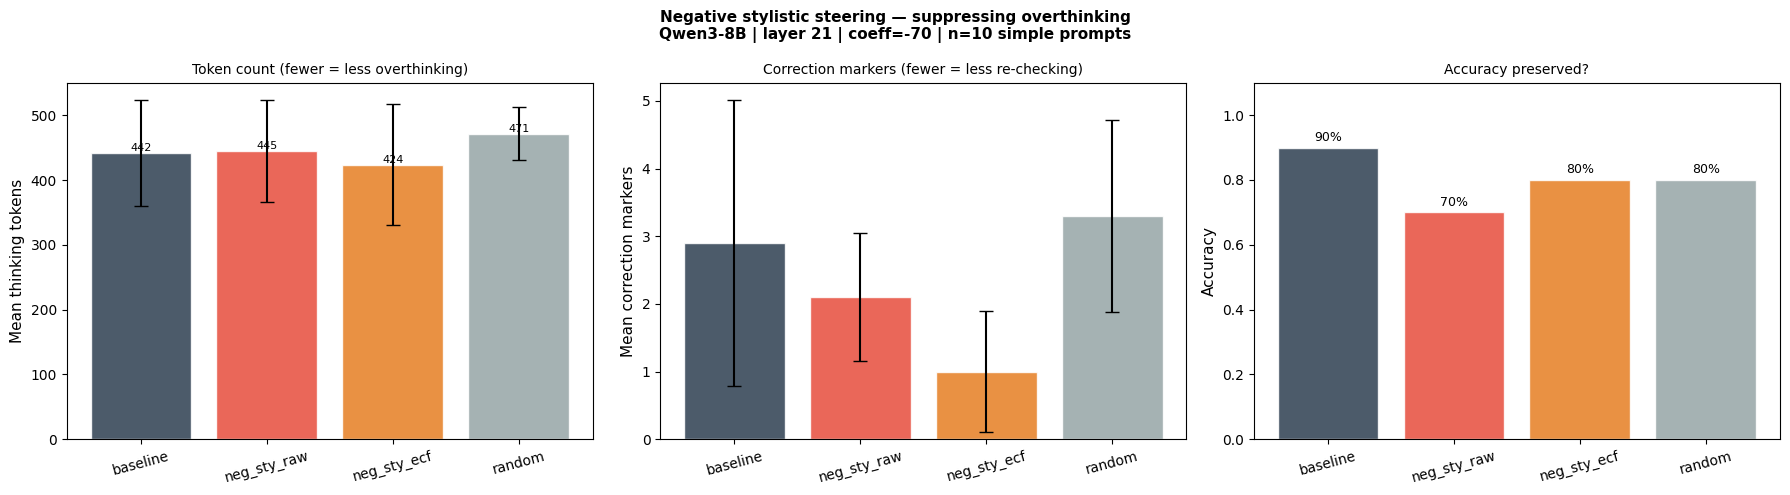

In [42]:
# ── Part 2 statistics ─────────────────────────────────────────────
print("\n" + "="*65)
print("PART 2 RESULTS")
print("="*65)

all_vecs_p2 = ['baseline'] + list(NEG_VECTORS.keys())
for vn in all_vecs_p2:
    d   = results_neg[vn]
    acc = sum(d['correct']) / len(d['correct'])
    print(f"  {vn:>14}: tokens={np.mean(d['tokens']):.0f}±{np.std(d['tokens']):.0f}"
          f"  markers={np.mean(d['markers']):.2f}  "
          f"acc={acc:.0%} ({sum(d['correct'])}/{len(d['correct'])})")

rand_tok = results_neg['random']['tokens']
print("\n  Mann-Whitney U (H1: stylistic vector has FEWER tokens than random):")
for vn in ['neg_sty_raw', 'neg_sty_ecf']:
    vec_tok = results_neg[vn]['tokens']
    stat, p = stats.mannwhitneyu(vec_tok, rand_tok, alternative='less')
    sig = 'p<0.05 ✓' if p < 0.05 else 'not significant'
    print(f"    {vn} vs random: p={p:.4f}  {sig}")

# ── Part 2 figure ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors2 = ['#2c3e50', '#e74c3c', '#e67e22', '#95a5a6']

# tokens
means_tok = [np.mean(results_neg[vn]['tokens']) for vn in all_vecs_p2]
stds_tok  = [np.std(results_neg[vn]['tokens'])  for vn in all_vecs_p2]
axes[0].bar(all_vecs_p2, means_tok, color=colors2, alpha=0.85,
            yerr=stds_tok, capsize=5, edgecolor='white')
for bar, val in zip(axes[0].patches, means_tok):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 3,
                 f'{val:.0f}', ha='center', fontsize=8)
axes[0].set_ylabel('Mean thinking tokens', fontsize=11)
axes[0].set_title('Token count (fewer = less overthinking)', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)

# markers
means_m2 = [np.mean(results_neg[vn]['markers']) for vn in all_vecs_p2]
stds_m2  = [np.std(results_neg[vn]['markers'])  for vn in all_vecs_p2]
axes[1].bar(all_vecs_p2, means_m2, color=colors2, alpha=0.85,
            yerr=stds_m2, capsize=5, edgecolor='white')
axes[1].set_ylabel('Mean correction markers', fontsize=11)
axes[1].set_title('Correction markers (fewer = less re-checking)', fontsize=10)
axes[1].tick_params(axis='x', rotation=15)

# accuracy
accs2 = [sum(results_neg[vn]['correct'])/len(SIMPLE_PROMPTS)
         for vn in all_vecs_p2]
bars  = axes[2].bar(all_vecs_p2, accs2, color=colors2,
                     alpha=0.85, edgecolor='white')
axes[2].set_ylim(0, 1.1)
for bar, val in zip(bars, accs2):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.0%}', ha='center', fontsize=9)
axes[2].set_ylabel('Accuracy', fontsize=11)
axes[2].set_title('Accuracy preserved?', fontsize=10)
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle(
    f'Negative stylistic steering — suppressing overthinking\n'
    f'Qwen3-8B | layer {STEERING_LAYER} | coeff={NEG_COEFF} | '
    f'n={len(SIMPLE_PROMPTS)} simple prompts',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/neg_stylistic_vs_random.png',
            dpi=130, bbox_inches='tight')
plt.show()
plt.close()

какие не correct?

In [14]:
# check which prompts got correct=False and why
with open('/kaggle/input/datasets/svvikhlyantseva/neg-stylistic-vs-random/neg_stylistic_vs_random.json', 'r') as f:
    neg_records = json.load(f)

print("Cases where correct=False:\n")
for record in neg_records:
    gt = record.get('gt', '')
    prompt = record['prompt']
    for cond in record['conditions']:
        thinking = cond.get('thinking', '')
        answer   = cond.get('answer', '')
        combined = (answer + thinking).lower()
        # apply unicode fix
        for src, dst in [('₀','0'),('₁','1'),('₂','2'),('₃','3'),
                         ('₄','4'),('₅','5'),('₆','6'),('₇','7'),
                         ('₈','8'),('₉','9')]:
            combined = combined.replace(src, dst)
        gt_norm = gt.lower()
        for src, dst in [('₀','0'),('₁','1'),('₂','2'),('₃','3'),
                         ('₄','4'),('₅','5'),('₆','6'),('₇','7'),
                         ('₈','8'),('₉','9')]:
            gt_norm = gt_norm.replace(src, dst)
        correct = int(gt_norm in combined)
        if not correct:
            print(f"PROMPT: {prompt}")
            print(f"VECTOR: {cond['vector']}  coeff={cond['coeff']}")
            print(f"GT: '{gt}'")
            print(f"Answer: '{answer[:200]}'")
            print(f"Thinking snippet: '{thinking[:300]}'")
            print()

Cases where correct=False:

PROMPT: What is the capital of Australia? Think step by step.
VECTOR: neg_sty_raw  coeff=-70
GT: 'Canberra'
Answer: ''
Thinking snippet: 'Okay, so I need to figure out the capital of Australia. Let me start by recalling what I know. I remember that Australia is a country in the southern hemisphere, and it's known for things like the Great Barrier Reef, Uluru, and its unique wildlife. But when it comes to capitals, I'm a bit fuzzy.

Fi'

PROMPT: How many days are in a leap year? Think carefully.
VECTOR: neg_sty_raw  coeff=-70
GT: '366'
Answer: ''
Thinking snippet: 'Okay, so the question is asking how many days are in a leap year. Hmm, let me think. I remember that a regular year has 365 days, right? But a leap year is different. I think it has one extra day. But wait, which day is that?

I recall that leap years occur every four years. So maybe they add an ext'

PROMPT: How many days are in a leap year? Think carefully.
VECTOR: random  coeff=-70
GT: '366'
Ans

In [18]:
from datasets import load_dataset

simpleqa = load_dataset(
    "basicv8vc/SimpleQA", split="test"
).shuffle(seed=42)

EXTRA_PROMPTS = []
EXTRA_GT      = {}

for item in simpleqa:
    q   = item['problem'].strip()
    ans = item['answer'].strip()

    # skip if answer is very long or contains commas (hard to match exactly)
    if len(ans) > 40 or ',' in ans:
        continue
    # skip if question is very long
    if len(q) > 150:
        continue

    EXTRA_PROMPTS.append(q)
    EXTRA_GT[q] = ans

    if len(EXTRA_PROMPTS) == 20:
        break

print(f"Extra prompts from SimpleQA: {len(EXTRA_PROMPTS)}")
for p in EXTRA_PROMPTS:
    print(f"  Q: {p[:70]}  |  GT: '{EXTRA_GT[p]}'")

Extra prompts from SimpleQA: 20
  Q: What year was the municipality of Ramiriquí, Boyacá, Colombia, founded  |  GT: '1541'
  Q: What prize was Jean Chazy awarded in 1922 by the French Academy of Sci  |  GT: 'Prix Benjamin Valz'
  Q: What were the first, middle, and last names of the third deputy speake  |  GT: 'Cecil Edward Gibbon'
  Q: What is the Glottolog language code of the Aralle-Tabulahan language?  |  GT: 'aral1243'
  Q: What's the name of the active president of the United States in Season  |  GT: 'President Kelly Wade'
  Q: Who won the 2015 Maine State Pumpkin and Squash Weigh-Off, held at the  |  GT: 'Edwin Pierpont'
  Q: In which year was John B. Goodenough elected a Foreign Member of the R  |  GT: '2010'
  Q: Which Ivy League university granted psychologist Robert Rutherford Hol  |  GT: 'Harvard'
  Q: What is the name of the former Prime Minister of Iceland who worked as  |  GT: 'Jóhanna Sigurðardóttir'
  Q: In which year did Atul Gawande earn an M.A. in Philosophy, Politi

In [28]:
# 10 additional simple factual and arithmetic prompts
# similar in difficulty to the original set (Australia, leap year, etc.)
EXTRA_PROMPTS = [
    "What is the largest ocean on Earth?",
    "How many legs does a spider have?",
    "What is the boiling point of water in degrees Celsius?",
    "What is 15 minus 7?",
    "What planet is closest to the Sun?",
    "How many continents are there on Earth?",
    "What is the square root of 16?",
    "In which country is the Eiffel Tower located?",
    "How many hours are in a day?",
    "What is the sum of angles in a triangle in degrees?",
]

EXTRA_GT = {
    "What is the largest ocean on Earth?"                   : "Pacific",
    "How many legs does a spider have?"                     : "eight",
    "What is the boiling point of water in degrees Celsius?": "100",
    "What is 15 minus 7?"                                   : "8",
    "What planet is closest to the Sun?"                    : "Mercury",
    "How many continents are there on Earth?"               : "seven",
    "What is the square root of 16?"                        : "4",
    "In which country is the Eiffel Tower located?"         : "France",
    "How many hours are in a day?"                          : "24",
    "What is the sum of angles in a triangle in degrees?"   : "180",
}

print(f"Extra prompts: {len(EXTRA_PROMPTS)}")
for p in EXTRA_PROMPTS:
    print(f"  Q: {p}  |  GT: '{EXTRA_GT[p]}'")

Extra prompts: 10
  Q: What is the largest ocean on Earth?  |  GT: 'Pacific'
  Q: How many legs does a spider have?  |  GT: 'eight'
  Q: What is the boiling point of water in degrees Celsius?  |  GT: '100'
  Q: What is 15 minus 7?  |  GT: '8'
  Q: What planet is closest to the Sun?  |  GT: 'Mercury'
  Q: How many continents are there on Earth?  |  GT: 'seven'
  Q: What is the square root of 16?  |  GT: '4'
  Q: In which country is the Eiffel Tower located?  |  GT: 'France'
  Q: How many hours are in a day?  |  GT: '24'
  Q: What is the sum of angles in a triangle in degrees?  |  GT: '180'


In [32]:
# ── run the same experiment on extra prompts ──────────────────────
NEG_COEFF = -70
STEERING_LAYER = 21

NEG_VECTORS = {
    'neg_sty_raw' : sv_sty_raw,
    'neg_sty_ecf' : sv_sty_ecf,
    'random'      : sv_rand,
}

extra_records = []

print("\n" + "="*65)
print(f"EXTRA PROMPTS  |  coeff={NEG_COEFF}  |  layer={STEERING_LAYER}")
print("="*65)

for p_idx, prompt_text in enumerate(EXTRA_PROMPTS):
    gt     = EXTRA_GT[prompt_text]
    record = {'prompt': prompt_text[:80], 'gt': gt, 'conditions': []}
    print(f"\n[{p_idx+1}/{len(EXTRA_PROMPTS)}] {prompt_text[:60]}")
    print(f"  GT: {gt}")

    # baseline
    torch.cuda.empty_cache(); gc.collect()
    thinking_b, answer_b, closed_b = generate_steered(
        model, tokenizer, prompt_text,
        steering_vector=None, coeff=0,
        steering_layer=None, max_new_tokens=500,
    )
    _, n_b_m = count_correction_markers(thinking_b)
    n_b_tok  = len(tokenizer.encode(thinking_b))
    corr_b   = score_answer_fixed(answer_b, thinking_b, gt)
    print(f"  [baseline] markers={n_b_m} tokens={n_b_tok} "
          f"correct={bool(corr_b)}")

    record['conditions'].append({
        'vector': 'baseline', 'coeff': 0,
        'markers': n_b_m, 'tokens': n_b_tok, 'correct': corr_b,
        'thinking': thinking_b[:300], 'answer': answer_b[:150],
    })

    for vec_name, sv in NEG_VECTORS.items():
        torch.cuda.empty_cache(); gc.collect()

        thinking_s, answer_s, closed_s = generate_steered(
            model, tokenizer, prompt_text,
            steering_vector=sv,
            coeff=NEG_COEFF,
            steering_layer=STEERING_LAYER,
            max_new_tokens=500,
        )
        _, n_s_m = count_correction_markers(thinking_s)
        n_s_tok  = len(tokenizer.encode(thinking_s))
        corr_s   = score_answer_fixed(answer_s, thinking_s, gt)

        print(f"  [{vec_name} c={NEG_COEFF}] markers={n_s_m} "
              f"tokens={n_s_tok} correct={bool(corr_s)}")

        record['conditions'].append({
            'vector': vec_name, 'coeff': NEG_COEFF,
            'markers': n_s_m, 'tokens': n_s_tok, 'correct': corr_s,
            'thinking': thinking_s[:300], 'answer': answer_s[:150],
        })

    extra_records.append(record)
    with open(f'{OUTPUT_DIR}/neg_stylistic_extra.json', 'w') as f:
        json.dump(extra_records, f, ensure_ascii=False, indent=2)


EXTRA PROMPTS  |  coeff=-70  |  layer=21

[1/10] What is the largest ocean on Earth?
  GT: Pacific
  [baseline] markers=2 tokens=332 correct=True
  [neg_sty_raw c=-70] markers=4 tokens=500 correct=True
  [neg_sty_ecf c=-70] markers=1 tokens=465 correct=True
  [random c=-70] markers=6 tokens=500 correct=True

[2/10] How many legs does a spider have?
  GT: eight
  [baseline] markers=5 tokens=500 correct=True
  [neg_sty_raw c=-70] markers=2 tokens=500 correct=True
  [neg_sty_ecf c=-70] markers=1 tokens=436 correct=True
  [random c=-70] markers=4 tokens=500 correct=True

[3/10] What is the boiling point of water in degrees Celsius?
  GT: 100
  [baseline] markers=2 tokens=332 correct=True
  [neg_sty_raw c=-70] markers=2 tokens=440 correct=True
  [neg_sty_ecf c=-70] markers=1 tokens=424 correct=True
  [random c=-70] markers=3 tokens=478 correct=True

[4/10] What is 15 minus 7?
  GT: 8
  [baseline] markers=2 tokens=500 correct=True
  [neg_sty_raw c=-70] markers=1 tokens=500 correct=True
  [n

In [36]:
# ── COMBINED STATISTICS ───────────────────────────────────────────
# load original results
with open('/kaggle/input/datasets/svvikhlyantseva/neg-stylistic-vs-random/neg_stylistic_vs_random.json', 'r') as f:
    orig_records = json.load(f)

all_records_combined = orig_records + extra_records

# rebuild results dict from all records
vec_names_all = set()
for r in all_records_combined:
    for c in r['conditions']:
        vec_names_all.add(c['vector'])

results_combined = {vn: {'markers': [], 'tokens': [], 'correct': []}
                    for vn in vec_names_all}

for record in all_records_combined:
    gt = record.get('gt', '')
    for cond in record['conditions']:
        vn = cond['vector']
        results_combined[vn]['markers'].append(cond.get('markers', 0))
        results_combined[vn]['tokens'].append(cond.get('tokens', 0))
        results_combined[vn]['correct'].append(
            score_answer_fixed(
                cond.get('answer', ''),
                cond.get('thinking', ''),
                gt
            )
        )

n_total = len(all_records_combined)
print("\n" + "="*65)
print(f"COMBINED RESULTS (n={n_total} prompts)")
print("="*65)

all_vecs = ['baseline'] + [v for v in vec_names_all if v != 'baseline']
for vn in all_vecs:
    d   = results_combined[vn]
    acc = sum(d['correct']) / len(d['correct']) if d['correct'] else 0
    print(f"  {vn:>15}: tokens={np.mean(d['tokens']):.0f}"
          f"±{np.std(d['tokens']):.0f}  "
          f"markers={np.mean(d['markers']):.2f}  "
          f"acc={acc:.0%} ({sum(d['correct'])}/{len(d['correct'])})")

rand_tok = results_combined['random']['tokens']
rand_m   = results_combined['random']['markers']

print(f"\n  Mann-Whitney U (H1: stylistic vector FEWER tokens than random):")
for vn in ['neg_sty_raw', 'neg_sty_ecf']:
    vec_tok = results_combined[vn]['tokens']
    stat, p = stats.mannwhitneyu(vec_tok, rand_tok, alternative='less')
    sig = 'p<0.05 ✓' if p < 0.05 else 'not significant'
    print(f"    {vn} vs random: p={p:.4f}  {sig}")

print(f"\n  Mann-Whitney U (H1: stylistic vector FEWER markers than random):")
for vn in ['neg_sty_raw', 'neg_sty_ecf']:
    vec_m = results_combined[vn]['markers']
    stat, p = stats.mannwhitneyu(vec_m, rand_m, alternative='less')
    sig = 'p<0.05 ✓' if p < 0.05 else 'not significant'
    print(f"    {vn} vs random: p={p:.4f}  {sig}")

# save combined
with open(f'{OUTPUT_DIR}/neg_stylistic_combined.json', 'w') as f:
    json.dump(all_records_combined, f, ensure_ascii=False, indent=2)
print(f"\nSaved: {OUTPUT_DIR}/neg_stylistic_combined.json")


COMBINED RESULTS (n=20 prompts)
         baseline: tokens=421±102  markers=2.90  acc=80% (16/20)
           random: tokens=470±59  markers=3.55  acc=70% (14/20)
      neg_sty_ecf: tokens=427±86  markers=1.00  acc=70% (14/20)
      neg_sty_raw: tokens=448±87  markers=2.05  acc=70% (14/20)

  Mann-Whitney U (H1: stylistic vector FEWER tokens than random):
    neg_sty_raw vs random: p=0.3742  not significant
    neg_sty_ecf vs random: p=0.0250  p<0.05 ✓

  Mann-Whitney U (H1: stylistic vector FEWER markers than random):
    neg_sty_raw vs random: p=0.0003  p<0.05 ✓
    neg_sty_ecf vs random: p=0.0000  p<0.05 ✓

Saved: /kaggle/working/logit_lens_output/neg_stylistic_combined.json


In [1]:
with open('/kaggle/input/datasets/svvikhlyantseva/neg-stylistic-combined/neg_stylistic_combined.json', 'r') as f:
    combined = json.load(f)

NameError: name 'json' is not defined

In [14]:
# find all cases where correct=0 after fix and see what GT is
for record in combined:
    gt = record.get('gt', '')
    for cond in record['conditions']:
        fixed = score_answer_fixed(
            cond.get('answer', ''),
            cond.get('thinking', ''),
            gt
        )
        if fixed == 0:
            print(f"Q: {record['prompt'][:60]}")
            print(f"GT: '{gt}'")
            print(f"vector: {cond['vector']}  closed={cond.get('closed')}")
            print(f"answer: '{cond.get('answer','')[:100]}'")
            print(f"thinking end: '...{cond.get('thinking','')[-100:]}'")
            print()

Q: What is the capital of Australia? Think step by step.
GT: 'Canberra'
vector: neg_sty_raw  closed=False
answer: ''
thinking end: '...d a continent. The country is called the Commonwealth of Australia, and it's a sovereign nation. The'

Q: How many days are in a leap year? Think carefully.
GT: '366'
vector: neg_sty_raw  closed=False
answer: ''
thinking end: '...leap year, it has 29. That must be it. So if I take the regular number of days in a year, which is 3'

Q: How many days are in a leap year? Think carefully.
GT: '366'
vector: random  closed=False
answer: ''
thinking end: '... has something to do with the Earth's orbit around the Sun. The Earth takes about 365.25 days to orb'

Q: What is 2 + 2? Explain your answer step by step.
GT: '4'
vector: neg_sty_raw  closed=False
answer: ''
thinking end: '...many apples do I have in total? Let me count. One apple, two apples, three apples, four apples. Wait'

Q: What is 2 + 2? Explain your answer step by step.
GT: '4'
vector: neg_sty_ecf  

In [20]:
import json
import numpy as np
from scipy import stats

with open('/kaggle/input/datasets/svvikhlyantseva/neg-stylistic-combined/neg_stylistic_combined.json', 'r') as f:
    combined = json.load(f)

def score_answer_fixed(answer_text, thinking_text, ground_truth):
    """Handles unicode subscripts."""
    text = (answer_text + ' ' + thinking_text).lower()
    gt   = ground_truth.lower()
    for src, dst in [('₀','0'),('₁','1'),('₂','2'),('₃','3'),
                     ('₄','4'),('₅','5'),('₆','6'),('₇','7'),
                     ('₈','8'),('₉','9')]:
        text = text.replace(src, dst)
        gt   = gt.replace(src, dst)
    return int(gt in text)

# collect vec names
vec_names = set()
for r in combined:
    for c in r['conditions']:
        vec_names.add(c['vector'])

results = {vn: {'markers': [], 'tokens': [], 'correct': []}
           for vn in vec_names}

for record in combined:
    gt = record.get('gt', '')
    for cond in record['conditions']:
        vn = cond['vector']
        results[vn]['markers'].append(cond.get('markers', 0))
        results[vn]['tokens'].append(cond.get('tokens', 0))
        if cond.get('correct') == 0:
            # recompute correct with unicode fix
            results[vn]['correct'].append(score_answer_fixed(cond.get('answer', ''), cond.get('thinking', ''), gt))
        else:
            results[vn]['correct'].append(cond.get('correct', 0))  # use stored value

print(f"n={len(combined)} simple prompts")
print("=" * 65)
print("COMBINED RESULTS (corrected accuracy)")
print("=" * 65)

order = ['baseline', 'neg_sty_ecf', 'neg_sty_raw', 'random']
for vn in order:
    if vn not in results:
        continue
    d   = results[vn]
    acc = sum(d['correct']) / len(d['correct'])
    print(f"  {vn:>15}: tokens={np.mean(d['tokens']):.0f}"
          f"±{np.std(d['tokens']):.0f}  "
          f"markers={np.mean(d['markers']):.2f}  "
          f"acc={acc:.0%} ({sum(d['correct'])}/{len(d['correct'])})")

rand_tok = results['random']['tokens']
rand_m   = results['random']['markers']

print("\n  Mann-Whitney U (H1: fewer tokens than random):")
for vn in ['neg_sty_ecf', 'neg_sty_raw']:
    if vn not in results:
        continue
    stat, p = stats.mannwhitneyu(
        results[vn]['tokens'], rand_tok, alternative='less'
    )
    print(f"    {vn}: p={p:.4f}  {'p<0.05 ✓' if p < 0.05 else 'not significant'}")

print("\n  Mann-Whitney U (H1: fewer markers than random):")
for vn in ['neg_sty_ecf', 'neg_sty_raw']:
    if vn not in results:
        continue
    stat, p = stats.mannwhitneyu(
        results[vn]['markers'], rand_m, alternative='less'
    )
    print(f"    {vn}: p={p:.4f}  {'p<0.05 ✓' if p < 0.05 else 'not significant'}")

n=20 prompts
COMBINED RESULTS (corrected accuracy)
         baseline: tokens=421±102  markers=2.90  acc=100% (20/20)
      neg_sty_ecf: tokens=427±86  markers=1.00  acc=100% (20/20)
      neg_sty_raw: tokens=448±87  markers=2.05  acc=100% (20/20)
           random: tokens=470±59  markers=3.55  acc=100% (20/20)

  Mann-Whitney U (H1: fewer tokens than random):
    neg_sty_ecf: p=0.0250  p<0.05 ✓
    neg_sty_raw: p=0.3742  not significant

  Mann-Whitney U (H1: fewer markers than random):
    neg_sty_ecf: p=0.0000  p<0.05 ✓
    neg_sty_raw: p=0.0003  p<0.05 ✓
